# Ten trajectories with implicit ABBA

This small experiment integrates ten guiding-centre initial conditions together with `ImplicitABBA1` and displays their planar trajectories. All parameters that determine the result are explicit below.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from dynamics import GuidingCenterDynamics
from simulation import (
    ImplicitABBA1,
    InitialValueProblem,
    SimulationRequest,
    simulate,
)
from studies import RandomPotentialConfig, random_gc_configuration
from visualization import (
    animate_gc_particle_trajectories,
    display_animation,
)

## Reproducible configuration

The ten initial positions are sampled inside the central half of the periodic cell so the paths remain easy to read. The random potential and the initial positions use independent fixed seeds.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=16,
    nx=48,
    ny=48,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

trajectory_count = 10
initial_condition_seed = 2026
initial_configuration = random_gc_configuration(
    potential,
    particle_count=trajectory_count,
    seed=initial_condition_seed,
    x_bounds=(np.pi / 2, 3 * np.pi / 2),
    y_bounds=(np.pi / 2, 3 * np.pi / 2),
)

rho = 0.3
t_span = (0.0, 2 * np.pi)
integration_step = np.pi / 80
output_sample_count = 161

dynamics = GuidingCenterDynamics(potential, rho=rho)
problem = InitialValueProblem(dynamics, initial_configuration)
method = ImplicitABBA1(
    newton_absolute_tolerance=1e-13,
    newton_relative_tolerance=1e-12,
    newton_max_iterations=12,
    progress=False,
)
request = SimulationRequest.uniform(
    t_span=t_span,
    max_step=integration_step,
    sample_count=output_sample_count,
)

print(potential_config)
print(
    f"Trajectories: {trajectory_count}; rho={rho}; "
    f"t={t_span}; step=pi/80; saved states={output_sample_count}"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=16, nx=48, ny=48, seed=27, interpolation_order=5)
Trajectories: 10; rho=0.3; t=(0.0, 6.283185307179586); step=pi/80; saved states=161


## Integration

In [3]:
solution = simulate(problem, method, request)
x, y = solution.positions()

print(f"Fixed steps: {solution.diagnostics['step_count']}")
print(
    "Maximum Newton corrections in one step: "
    f"{int(np.max(solution.diagnostics['newton_iterations']))}"
)

Fixed steps: 160
Maximum Newton corrections in one step: 1


## Planar trajectories

Circles mark the initial positions and crosses mark the final positions.

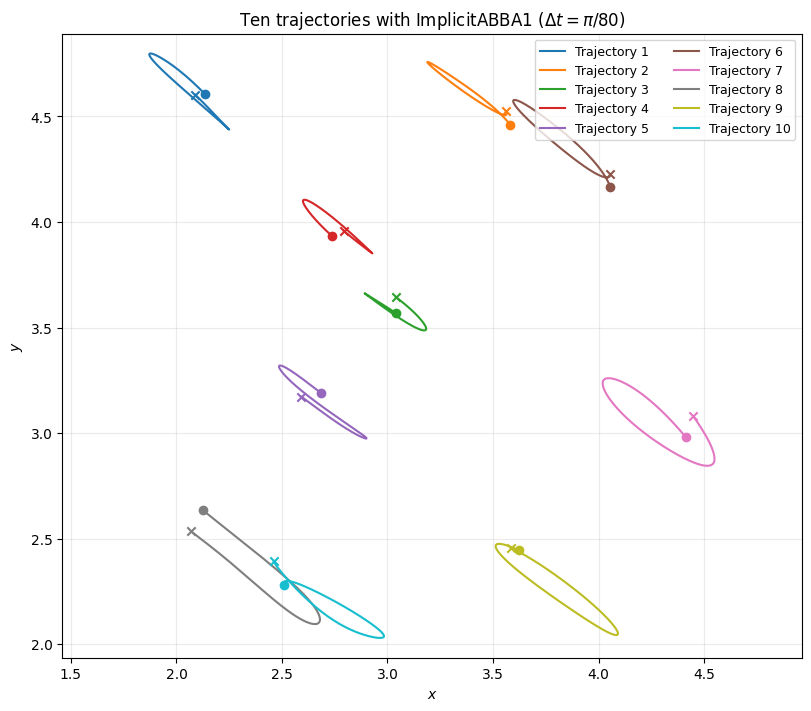

In [4]:
figure, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)

for index, (x_values, y_values) in enumerate(zip(x, y, strict=True), start=1):
    line = axis.plot(x_values, y_values, label=f"Trajectory {index}")[0]
    axis.scatter(x_values[0], y_values[0], color=line.get_color(), zorder=3)
    axis.scatter(
        x_values[-1],
        y_values[-1],
        color=line.get_color(),
        marker="x",
        zorder=3,
    )

axis.set(
    xlabel=r"$x$",
    ylabel=r"$y$",
    title=r"Ten trajectories with ImplicitABBA1 ($\Delta t=\pi/80$)",
)
axis.set_aspect("equal", adjustable="datalim")
axis.grid(alpha=0.25)
axis.legend(ncols=2, fontsize=9);

## Potential, electric field, and perpendicular motion

The background is the gyroaveraged effective potential used by the guiding-centre dynamics. Black arrows show its electric field. Gold arrows show the instantaneous guiding-centre drift $\dot z=(E_y,-E_x)$ at each particle, which is perpendicular to the local electric field.

In [5]:
animation = animate_gc_particle_trajectories(
    dynamics.effective_potential,
    solution,
    frames=81,
    interval=100,
    show_electric_field=True,
    show_perpendicular_drift=True,
)

display_animation(animation, embed_limit_mb=30.0)